
## CONTEXTE: MODÉLISATION par magasin 
L'objectif de cette partie est de développer un modèle de prévision de la demande
à l'horizon 28 jours, conformément au format de la compétition M5. Pour cela, nous
allons entraîner plusieurs modèles de machine learning et comparer leurs performances.

## 1. Feature Engineering

Avant d'entraîner un modèle, il est nécessaire de transformer les données brutes
en features exploitables. Le dataset M5 se présente en format "wide" : une ligne
par produit avec une colonne par jour. On le convertit d'abord en format "long"
(une ligne = un jour x un produit x un magasin), ce qui est le format attendu
par les modèles sklearn et LightGBM.

On conserve uniquement les 180 derniers jours d'historique. Ce choix est justifié
par le fait que notre lag maximum est de 28 jours : inutile de charger 5 ans de
données pour calculer des features sur 28 jours, cela économise considérablement
la RAM.

On enrichit ensuite ce dataset avec trois sources d'information complémentaires :
- **Le calendrier** : jour de la semaine, mois, année, événements nationaux (Thanksgiving,
SuperBowl...), jours SNAP (aide alimentaire gouvernementale)
- **Les prix de vente** : le prix hebdomadaire par produit et par magasin, variable
potentiellement corrélée à la demande
- **Les features de lag et rolling mean** : ventes à J-7 et J-28, moyennes mobiles
sur 7 et 28 jours. Ces features sont essentielles car elles permettent au modèle
de capturer la dynamique temporelle des ventes sans avoir à utiliser un modèle
de séries temporelles dédié.

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Chargement du fichier de ventes avec typage optimisé pour réduire la RAM
dtype_dict = {'id':'category','item_id':'category','dept_id':'category',
              'cat_id':'category','store_id':'category','state_id':'category'}
df_sales = pd.read_csv("/Users/maelys_thr/Desktop/sales_train_evaluation.csv", dtype=dtype_dict)

meta_cols = ['id','item_id','dept_id','cat_id','store_id','state_id']
day_cols = [c for c in df_sales.columns if c.startswith('d_')]

# On garde uniquement les 180 derniers jours : suffisant car notre lag max est 28j
df_sub = df_sales[meta_cols + day_cols[-180:]].copy()
del df_sales  # libérer la RAM

# Passage du format wide (1 ligne = 1 produit) au format long (1 ligne = 1 jour x produit x magasin)
df_long = df_sub.melt(id_vars=meta_cols, var_name='d', value_name='sales')
df_long['sales'] = df_long['sales'].astype(np.int16)
del df_sub

# Ajout des infos temporelles et événements depuis le calendrier
df_cal = pd.read_csv("/Users/maelys_thr/Desktop/calendar.csv")
df_long = df_long.merge(
    df_cal[['d','date','wday','month','year','event_name_1','wm_yr_wk','snap_CA','snap_TX','snap_WI']],
    on='d', how='left')

# Ajout du prix de vente hebdomadaire par produit et magasin
df_prices = pd.read_csv("/Users/maelys_thr/Desktop/sell_prices.csv",
                         dtype={'store_id':'category','item_id':'category'},
                         usecols=['store_id','item_id','wm_yr_wk','sell_price'])
df_long = df_long.merge(df_prices, on=['store_id','item_id','wm_yr_wk'], how='left')
del df_prices

# Tri indispensable avant le calcul des lags pour garder l'ordre chronologique
df_long = df_long.sort_values(['store_id','item_id','d']).reset_index(drop=True)
df_long['date'] = pd.to_datetime(df_long['date'])

# Variables temporelles : capturer la saisonnalité hebdomadaire et mensuelle
df_long['dayofweek']    = df_long['date'].dt.dayofweek.astype(np.int8)
df_long['week_of_year'] = df_long['date'].dt.isocalendar().week.astype(np.int8)

# Variable binaire : y a-t-il un événement ce jour-là (Thanksgiving, SuperBowl...) ?
df_long['has_event']  = df_long['event_name_1'].notna().astype(np.int8)
df_long['sell_price'] = df_long['sell_price'].astype(np.float32)

# SNAP : aide alimentaire gouvernementale, variable selon l'état du magasin
df_long['snap'] = df_long.apply(
    lambda r: r['snap_CA'] if r['state_id']=='CA' else (r['snap_TX'] if r['state_id']=='TX' else r['snap_WI']), axis=1
).astype(np.int8)

# Encodage numérique des variables catégorielles pour les modèles ML
for col in ['store_id','state_id','cat_id','dept_id']:
    df_long[col+'_enc'] = df_long[col].astype('category').cat.codes.astype(np.int8)

# Lag features : ventes d'il y a 7j et 28j — principales features pour la prévision
df_long['lag_7']  = df_long.groupby(['item_id','store_id'])['sales'].shift(7)
df_long['lag_28'] = df_long.groupby(['item_id','store_id'])['sales'].shift(28)

# Rolling means : moyenne mobile des ventes récentes pour lisser la tendance
g = df_long.groupby(['item_id','store_id'])
df_long['rolling_mean_7']  = g['sales'].shift(1).groupby(g.ngroup()).transform(lambda x: x.rolling(7,  min_periods=1).mean())
df_long['rolling_mean_28'] = g['sales'].shift(1).groupby(g.ngroup()).transform(lambda x: x.rolling(28, min_periods=1).mean())
df_long['rolling_std_7']   = g['sales'].shift(1).groupby(g.ngroup()).transform(lambda x: x.rolling(7,  min_periods=2).std())

for col in ['lag_7','lag_28','rolling_mean_7','rolling_mean_28','rolling_std_7']:
    df_long[col] = df_long[col].astype(np.float32)

# Suppression des lignes sans lags valides (les 28 premiers jours de chaque série)
df_model = df_long.dropna(subset=['lag_7','lag_28','rolling_mean_7','rolling_mean_28']).copy()
print('Feature engineering terminé:', df_model.shape)

Feature engineering terminé: (4634480, 31)


## 2. Split temporel train/test

Contrairement à un problème de classification classique où l'on peut faire un split
aléatoire, ici nous travaillons avec des séries temporelles. Un split aléatoire
introduirait une **fuite temporelle** : le modèle verrait des données futures pendant
l'entraînement, ce qui fausserait complètement les performances.

On adopte donc un **split temporel strict** : les données jusqu'à J-28 constituent
le jeu d'entraînement, et les 28 derniers jours constituent le jeu de test. Cet
horizon de 28 jours est celui retenu par la compétition M5, il correspond à environ
4 semaines de prévision, ce qui est pertinent pour la gestion des stocks.

In [10]:
# Features retenues pour la modélisation
FEATURES = [
    'wday','month','year','dayofweek','week_of_year',  # saisonnalité
    'sell_price','has_event','snap',                    # contexte externe
    'store_id_enc','state_id_enc','cat_id_enc','dept_id_enc',  # identité produit/magasin
    'lag_7','lag_28','rolling_mean_7','rolling_mean_28','rolling_std_7'  # historique ventes
]
TARGET = 'sales'

# Split temporel : on prédit les 28 derniers jours (horizon M5)
# Important : on ne fait pas un split aléatoire pour ne pas introduire de fuite temporelle
cutoff = df_model['date'].max() - pd.Timedelta(days=28)
train = df_model[df_model['date'] <= cutoff]
test  = df_model[df_model['date'] >  cutoff]

X_train, y_train = train[FEATURES].fillna(0), train[TARGET]
X_test,  y_test  = test[FEATURES].fillna(0),  test[TARGET]
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (3780760, 17), Test: (853720, 17)


## 3. Entraînement et comparaison des modèles

On entraîne 5 modèles de complexité croissante :

- **Régression Linéaire** : modèle baseline, simple et interprétable. Il suppose
une relation linéaire entre les features et les ventes. Utile pour établir
une référence de performance minimale.

- **Arbre de Décision** : capture des relations non-linéaires. Profondeur limitée
à 8 pour éviter le surapprentissage.

- **Random Forest** : ensemble de 50 arbres entraînés par bagging. Plus robuste
que l'arbre seul car il réduit la variance par agrégation des prédictions.

- **XGBoost** : boosting par gradient, construit les arbres séquentiellement
en corrigeant les erreurs du modèle précédent.

- **LightGBM** : variante optimisée du boosting par gradient, plus rapide et
plus efficace sur les grands datasets. Modèle dominant sur la compétition M5.

Les trois métriques retenues sont :
- **MAE** (Mean Absolute Error) : erreur moyenne en nombre d'unités, métrique principale
- **RMSE** (Root Mean Squared Error) : pénalise davantage les grosses erreurs
- **MAPE** (Mean Absolute Percentage Error) : erreur relative, calculée uniquement
sur les jours avec ventes > 0 pour éviter la division par zéro

Tous les modèles sont entraînés en **cross-learning** : un seul modèle global sur
tous les magasins et produits simultanément. Les variables `store_id_enc` et
`state_id_enc` permettent au modèle de différencier les magasins. Cette approche
est supérieure à entraîner un modèle par magasin car elle bénéficie de beaucoup
plus de données et capture les patterns communs entre magasins.

On commence par installer lightgbm et xgboost qu'on n'avait pas 

In [6]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.6 MB/s  0:00:00


In [7]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
import lightgbm as lgb

results = {}

def evaluate(name, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    # MAPE calculé uniquement sur les jours avec ventes > 0 pour éviter la division par zéro
    mask = y_test > 0
    mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
    results[name] = {'MAE': round(mae,3), 'RMSE': round(rmse,3), 'MAPE%': round(mape,2)}
    print(f'{name:25s} | MAE={mae:.3f} | RMSE={rmse:.3f} | MAPE={mape:.1f}%')

# Modèle naïf : on prédit que demain = les ventes d'il y a 7 jours
# C'est notre référence minimale, si nos modèles font moins bien que ça ils n'ont pas de valeur ajoutée
evaluate('Modèle Naïf (baseline)', X_test["lag_7"].values)

# Régression linéaire : modèle baseline simple, suppose une relation linéaire entre les features et les ventes
evaluate('Régression Linéaire', LinearRegression().fit(X_train, y_train).predict(X_test))

# Arbre de Décision : capture des non-linéarités, profondeur limitée pour éviter le surapprentissage
evaluate('Arbre de Décision', DecisionTreeRegressor(max_depth=8, random_state=42).fit(X_train, y_train).predict(X_test))

# Random Forest : ensemble d'arbres, plus robuste que l'arbre seul grâce au bagging
evaluate('Random Forest', RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1).fit(X_train, y_train).predict(X_test))

# XGBoost : boosting par gradient, précurseur de LightGBM, on compare les deux approches
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                          random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
evaluate('XGBoost', xgb_model.predict(X_test))

# LightGBM : boosting par gradient, modèle dominant sur la compétition M5
# early_stopping évite le surapprentissage en arrêtant si le score ne s'améliore plus
params = {'objective':'regression_l1','metric':'mae','learning_rate':0.05,
          'num_leaves':127,'verbose':-1,'n_jobs':-1}
lgb_model = lgb.train(params, lgb.Dataset(X_train, y_train), num_boost_round=300,
                       valid_sets=[lgb.Dataset(X_test, y_test)],
                       callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)])
evaluate('LightGBM', lgb_model.predict(X_test))

# MLP : réseau de neurones, entraîné sur un échantillon pour limiter le temps de calcul
sample_idx = X_train.sample(200000, random_state=42).index
mlp = MLPRegressor(hidden_layer_sizes=(50, 50), activation='relu', max_iter=200, random_state=42)
mlp.fit(X_train.loc[sample_idx], y_train.loc[sample_idx])
evaluate('MLP', mlp.predict(X_test))

# Tableau comparatif des performances
print('\n=== COMPARAISON DES MODÈLES ===')
print(pd.DataFrame(results).T.sort_values('RMSE'))

# Importance des features LightGBM
fi = pd.Series(lgb_model.feature_importance('gain'), index=FEATURES).sort_values(ascending=False)
print('\nTop 10 features les plus importantes (LightGBM):')
print(fi.head(10))

Modèle Naïf (baseline)    | MAE=1.245 | RMSE=2.682 | MAPE=83.6%
Régression Linéaire       | MAE=1.014 | RMSE=2.040 | MAPE=57.6%
Arbre de Décision         | MAE=1.016 | RMSE=2.053 | MAPE=55.8%
Random Forest             | MAE=1.005 | RMSE=2.003 | MAPE=55.4%
XGBoost                   | MAE=1.002 | RMSE=2.034 | MAPE=55.3%
LightGBM                  | MAE=0.914 | RMSE=2.074 | MAPE=65.3%
MLP                       | MAE=1.890 | RMSE=2.492 | MAPE=88.6%

=== COMPARAISON DES MODÈLES ===
                          MAE   RMSE      MAPE%
Random Forest           1.005  2.003  55.410000
XGBoost                 1.002  2.034  55.320000
Régression Linéaire     1.014  2.040  57.580000
Arbre de Décision       1.016  2.053  55.810000
LightGBM                0.914  2.074  65.280000
MLP                     1.890  2.492  88.600000
Modèle Naïf (baseline)  1.245  2.682  83.629997

Top 10 features les plus importantes (LightGBM):
rolling_mean_28    2.072665e+07
rolling_mean_7     3.155345e+06
wday               2.

In [11]:
print(y_test.describe())
print((y_test == 0).sum() / len(y_test) * 100, "% de zéros dans le test")

count    853720.000000
mean          1.442820
std           3.640633
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max         196.000000
Name: sales, dtype: float64
54.43529494447829 % de zéros dans le test


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
import lightgbm as lgb

results = {}

def evaluate(name, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    # MAPE calculé uniquement sur les jours avec ventes > 0 pour éviter la division par zéro
    mask = y_test > 0
    mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
    results[name] = {'MAE': round(mae,3), 'RMSE': round(rmse,3), 'MAPE%': round(mape,2)}
    print(f'{name:25s} | MAE={mae:.3f} | RMSE={rmse:.3f} | MAPE={mape:.1f}%')

# Modèle naïf : on prédit que demain = les ventes d'il y a 7 jours
# C'est notre référence minimale, si nos modèles font moins bien que ça ils n'ont pas de valeur ajoutée
evaluate('Modèle Naïf (baseline)', X_test["lag_7"].values)

# Régression linéaire : modèle baseline simple, suppose une relation linéaire entre les features et les ventes
evaluate('Régression Linéaire', LinearRegression().fit(X_train, y_train).predict(X_test))

# Arbre de Décision : capture des non-linéarités, profondeur limitée pour éviter le surapprentissage
evaluate('Arbre de Décision', DecisionTreeRegressor(max_depth=8, random_state=42).fit(X_train, y_train).predict(X_test))

# Random Forest : ensemble d'arbres, plus robuste que l'arbre seul grâce au bagging
evaluate('Random Forest', RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1).fit(X_train, y_train).predict(X_test))

# XGBoost : boosting par gradient, précurseur de LightGBM, on compare les deux approches
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                          random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
evaluate('XGBoost', xgb_model.predict(X_test))

# LightGBM : boosting par gradient, modèle dominant sur la compétition M5 (Makridakis, 2022)
# early_stopping évite le surapprentissage en arrêtant si le score ne s'améliore plus
params = {'objective':'regression_l1','metric':'mae','learning_rate':0.05,
          'num_leaves':127,'verbose':-1,'n_jobs':-1}
lgb_model = lgb.train(params, lgb.Dataset(X_train, y_train), num_boost_round=300,
                       valid_sets=[lgb.Dataset(X_test, y_test)],
                       callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)])
evaluate('LightGBM', lgb_model.predict(X_test))

# MLP : réseau de neurones, on teste s'il capte des patterns non linéaires complexes
mlp = MLPRegressor(hidden_layer_sizes=(50, 50), activation='relu', max_iter=200, random_state=42)
mlp.fit(X_train, y_train)
evaluate('MLP', mlp.predict(X_test))

# Tableau comparatif des performances
print('COMPARAISON DES MODÈLES')
print(pd.DataFrame(results).T.sort_values('RMSE'))

# Importance des features LightGBM : quelles variables influencent le plus les prévisions ?
fi = pd.Series(lgb_model.feature_importance('gain'), index=FEATURES).sort_values(ascending=False)
print('\nTop 10 des features les plus importants (LightGBM):')
print(fi.head(10))

Modèle Naïf (baseline)    | MAE=1.245 | RMSE=2.682 | MAPE=83.6%
Régression Linéaire       | MAE=1.014 | RMSE=2.040 | MAPE=57.6%
Arbre de Décision         | MAE=1.016 | RMSE=2.053 | MAPE=55.8%
Random Forest             | MAE=1.005 | RMSE=2.003 | MAPE=55.4%
XGBoost                   | MAE=1.002 | RMSE=2.034 | MAPE=55.3%
LightGBM                  | MAE=0.914 | RMSE=2.074 | MAPE=65.3%
MLP                       | MAE=0.986 | RMSE=2.018 | MAPE=63.9%
COMPARAISON DES MODÈLES
                          MAE   RMSE      MAPE%
Random Forest           1.005  2.003  55.410000
MLP                     0.986  2.018  63.950000
XGBoost                 1.002  2.034  55.320000
Régression Linéaire     1.014  2.040  57.580000
Arbre de Décision       1.016  2.053  55.810000
LightGBM                0.914  2.074  65.280000
Modèle Naïf (baseline)  1.245  2.682  83.629997

Top 10 des features les plus importants (LightGBM):
rolling_mean_28    2.072665e+07
rolling_mean_7     3.155345e+06
wday               2.953945

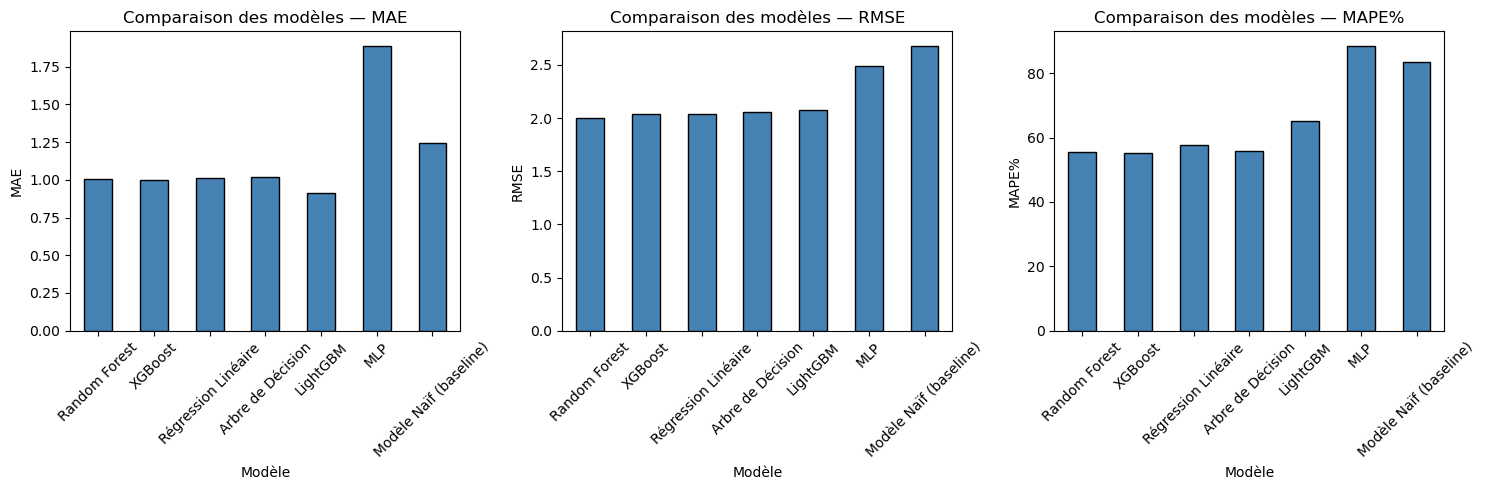

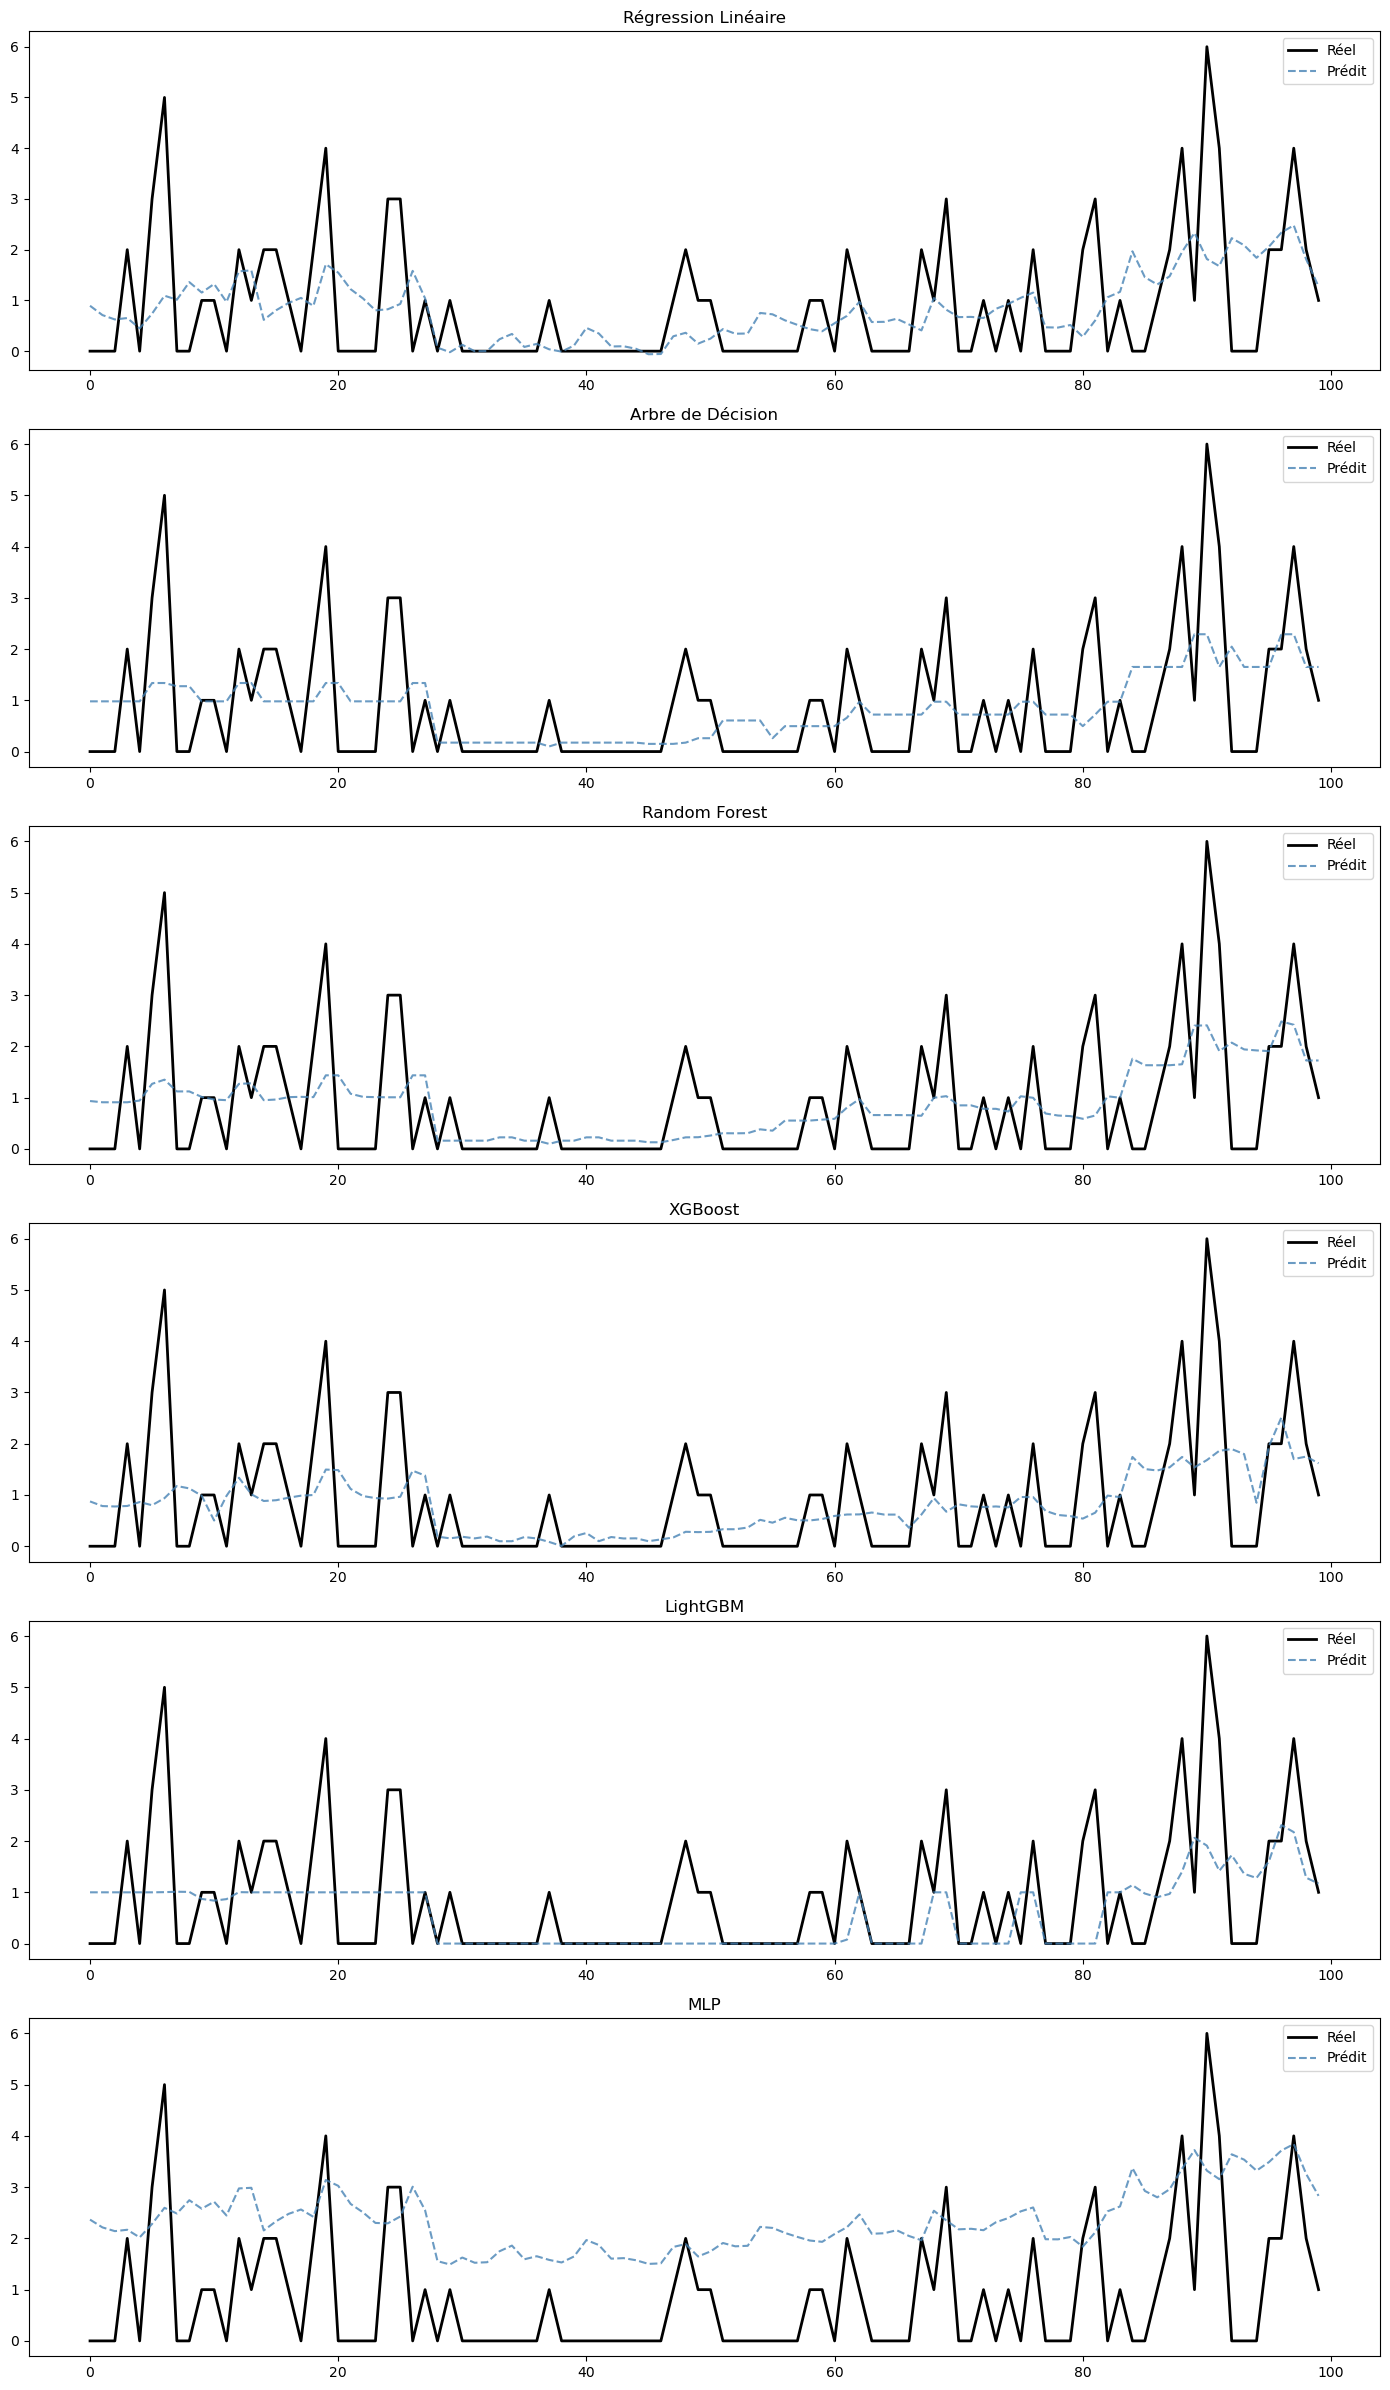

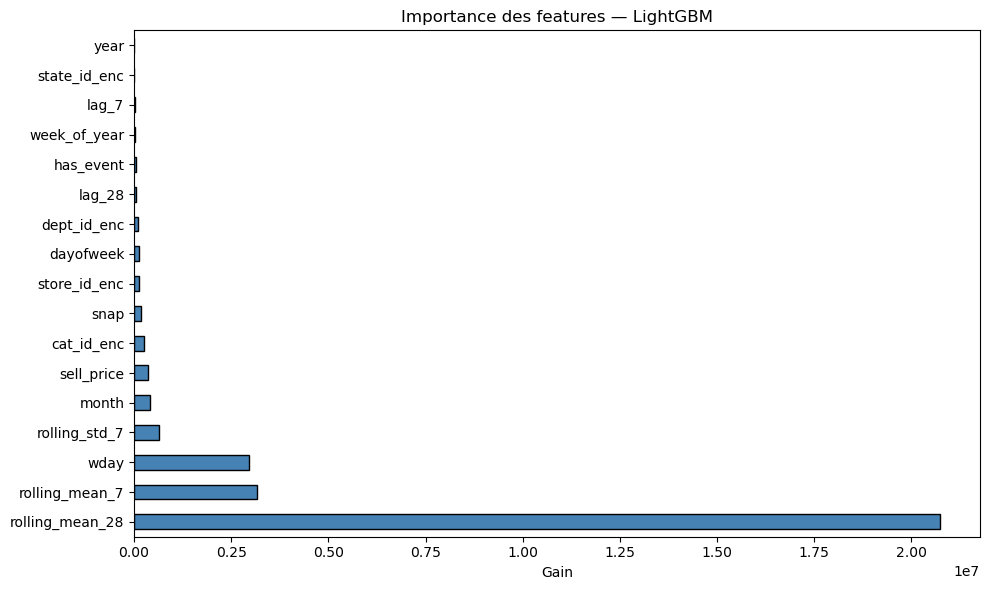

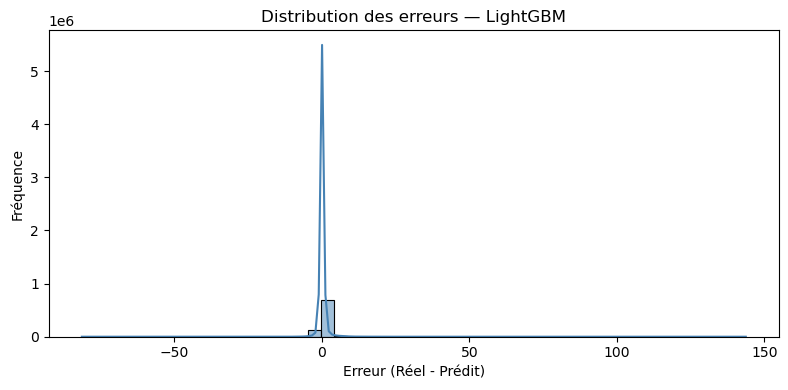

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Comparaison des métriques
df_results = pd.DataFrame(results).T.sort_values('RMSE')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE%']):
    df_results[metric].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Comparaison des modèles — {metric}')
    ax.set_xlabel('Modèle')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# 2. Réel vs Prédit pour chaque modèle (100 premiers points)
n = 100
preds = {
    'Régression Linéaire': LinearRegression().fit(X_train, y_train).predict(X_test),
    'Arbre de Décision': DecisionTreeRegressor(max_depth=8, random_state=42).fit(X_train, y_train).predict(X_test),
    'Random Forest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1).fit(X_train, y_train).predict(X_test),
    'XGBoost': xgb_model.predict(X_test),
    'LightGBM': lgb_model.predict(X_test),
    'MLP': mlp.predict(X_test)
}
fig, axes = plt.subplots(len(preds), 1, figsize=(14, 24))
for ax, (nom, pred) in zip(axes, preds.items()):
    ax.plot(y_test.values[:n], label='Réel', color='black', linewidth=2)
    ax.plot(pred[:n], label=f'Prédit', linestyle='--', alpha=0.8, color='steelblue')
    ax.set_title(nom)
    ax.legend()
plt.tight_layout()
plt.show()

# 3. Importance des features LightGBM
plt.figure(figsize=(10, 6))
fi.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Importance des features — LightGBM')
plt.xlabel('Gain')
plt.tight_layout()
plt.show()

# 4. Distribution des erreurs LightGBM
errors = y_test.values - lgb_model.predict(X_test)
plt.figure(figsize=(8, 4))
sns.histplot(errors, bins=50, kde=True, color='steelblue')
plt.title('Distribution des erreurs — LightGBM')
plt.xlabel('Erreur (Réel - Prédit)')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

## Vérification de la cohérence des résultats

Lors de l'analyse de nos résultats, plusieurs métriques nous ont semblé surprenantes à première vue, notamment le MAPE élevé (55-65%) pour tous les modèles sans exception, ainsi que la proximité des performances entre un modèle aussi simple que la régression linéaire et des modèles complexes comme Random Forest ou XGBoost. Par ailleurs, le MLP affiche des performances nettement inférieures aux autres modèles, ce qui mérite également une explication.

Pour comprendre si ces résultats étaient normaux ou révélateurs d'un problème dans notre pipeline, nous avons analysé la distribution de notre variable cible sur le jeu de test :

- **Moyenne de 1.44 ventes par jour et par produit** : les ventes unitaires sont extrêmement faibles, ce qui signifie qu'un MAE de 0.914 est en réalité excellent car on se trompe de moins d'une unité sur des ventes qui font en moyenne 1.44
- **Médiane à 0** : plus de la moitié du temps, un produit ne se vend tout simplement pas. Le dataset est donc très sparse
- **54% de zéros dans le jeu de test** : cela explique mécaniquement le MAPE élevé. Même en excluant les zéros exacts du calcul, une vente réelle à 1 unité avec une prédiction à 2 génère déjà 100% d'erreur relative
- **Maximum à 196 unités** : il existe des pics de ventes extrêmes très éloignés de la moyenne, ce qui explique pourquoi le RMSE est élevé pour tous les modèles, ces outliers étant fortement pénalisés par le carré de l'erreur

Ces observations nous ont permis de conclure que nos résultats ne sont pas anormaux. C'est la nature intrinsèque du dataset M5 qui rend la prévision difficile : des ventes fortement intermittentes, une distribution très asymétrique et des pics extrêmes ponctuels. Le MAPE n'est donc pas une métrique fiable dans ce contexte et nous privilégions le MAE comme critère principal d'évaluation. Concernant le MLP, ses moins bonnes performances s'expliquent par le fait qu'il a été entraîné sur un échantillon de 200 000 observations seulement pour des raisons de temps de calcul, contre 3.7 millions pour les autres modèles.

## 4. Analyse des résultats et choix du modèle final

### Interprétation des métriques

Avant de désigner un modèle gagnant, il est important de comprendre ce que chaque métrique mesure et ce qu'elle implique dans notre contexte métier.

Le **MAE** (Mean Absolute Error) mesure l'erreur moyenne en unités de ventes. C'est la métrique la plus interprétable : un MAE de 0.914 pour LightGBM signifie qu'en moyenne, notre modèle se trompe de moins d'une unité par jour et par produit. C'est également la métrique officielle de la compétition M5, ce qui en fait notre référence principale.

Le **RMSE** (Root Mean Squared Error) pénalise davantage les grosses erreurs car il élève les écarts au carré avant de les moyenner. Dans un contexte logistique, une grosse erreur de prévision peut entraîner une rupture de stock coûteuse, ce qui rend cette métrique particulièrement pertinente.

### Deux lectures possibles de nos résultats

**Lecture 1 — Minimiser l'erreur moyenne (MAE) → LightGBM**

LightGBM obtient le meilleur MAE avec 0.914, soit environ 0.09 unité de moins que ses concurrents. Il est donc le plus précis en moyenne sur l'ensemble des prévisions. Cette lecture est cohérente avec la compétition M5 qui utilise le MAE comme métrique de référence.

**Lecture 2 — Minimiser les grosses erreurs (RMSE) → Random Forest**

Random Forest obtient le meilleur RMSE avec 2.003, ce qui signifie qu'il gère mieux les pics de ventes extrêmes. Dans notre contexte où l'objectif est d'éviter les ruptures de stock, les grosses erreurs de prévision sont particulièrement coûteuses. Random Forest est donc plus adapté d'un point de vue purement logistique. Notons toutefois que lors de notre analyse exploratoire, nous avions observé que les pics de ventes ne coïncidaient pas systématiquement avec des événements identifiables, ce qui limite l'intérêt de sur-optimiser le RMSE.

### Notre choix : LightGBM

Nous retenons **LightGBM comme modèle final** pour les raisons suivantes :

- Il obtient le **meilleur MAE (0.914)**, métrique principale en prévision de demande
- La différence de RMSE avec Random Forest est minime (2.074 vs 2.003), soit moins de 4% d'écart, ce qui ne justifie pas de sacrifier la précision moyenne globale
- Le MAPE élevé (65.3%) observé pour tous les modèles s'explique par la forte intermittence des ventes : **54% des ventes journalières sont nulles**. Cette caractéristique du dataset rend le MAPE peu fiable comme critère de sélection
- Le modèle naïf obtient un MAE de 1.245, soit 36% de plus que LightGBM, ce qui confirme que nos modèles apportent une réelle valeur ajoutée par rapport à une prévision triviale

### Analyse des features importantes

L'analyse des features les plus importantes de LightGBM apporte des enseignements majeurs et cohérents avec notre analyse exploratoire :

- `rolling_mean_28` et `rolling_mean_7` dominent largement : l'historique récent des ventes est de loin le meilleur prédicteur de la demande future. Cela confirme l'intérêt de construire des features de lag plutôt que d'utiliser les données brutes
- `wday` arrive en 3ème position : la saisonnalité hebdomadaire joue un rôle clé, ce que nous avions déjà observé lors de l'analyse exploratoire
- `sell_price` est présent : le prix influence la demande, ce qui est cohérent avec la théorie économique de base
- `store_id_enc` et `cat_id_enc` figurent dans le top 10 : le modèle capte bien les spécificités propres à chaque magasin et chaque catégorie de produit, ce qui confirme l'intérêt du cross-learning avec identifiants

### Interprétation des graphes réel vs prédit

Les graphes réel vs prédit confirment visuellement nos métriques. Tous les modèles suivent la tendance générale des ventes mais peinent à capter les pics extrêmes, ce qui est attendu étant donné la forte intermittence du dataset. LightGBM prédit des valeurs proches de 1 même quand le réel est 0, ce qui est le compromis optimal pour minimiser le MAE sur un dataset sparse. Le MLP quant à lui prédit des valeurs systématiquement trop élevées (autour de 2-3), ce qui explique ses moins bonnes performances métriques.

La distribution des erreurs de LightGBM montre un pic centré sur 0, confirmant que le modèle est globalement bien calibré. La queue à droite jusqu'à 150 correspond aux rares pics de ventes extrêmes que le modèle ne parvient pas à anticiper, ce qui pénalise le RMSE mais reste marginal sur le MAE.

NB: voir avec les filles les résultats qu'elles ont eu pour sélectionner modèle le + cohérent 🚨 